In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearFlow


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [125]:

import scipy
def img_aug(x):
    xs_batch = x["image"]
    xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)
    
    # Normalize to [0, 1] and add small uniform noise for dequantization
    xs_batch = xs_batch.astype(jnp.float32) / 255.0
    xs_batch += np.random.uniform(0, 1/255, xs_batch.shape)
    # Move to [-1,1]
    xs_batch = 2*xs_batch - 1
    xs_batch = np.clip(xs_batch, -1.0, 1.0)
    return xs_batch[..., None] # Add channel dimension

In [208]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256, num_prefetch_host=16, num_prefetch_device=8, shard=False, host_transforms=img_aug, num_async_workers=2)

In [209]:
datastream = iter(loader)

In [210]:
%%timeit
y = next(datastream)
_ = y.block_until_ready()

53.9 μs ± 1.35 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


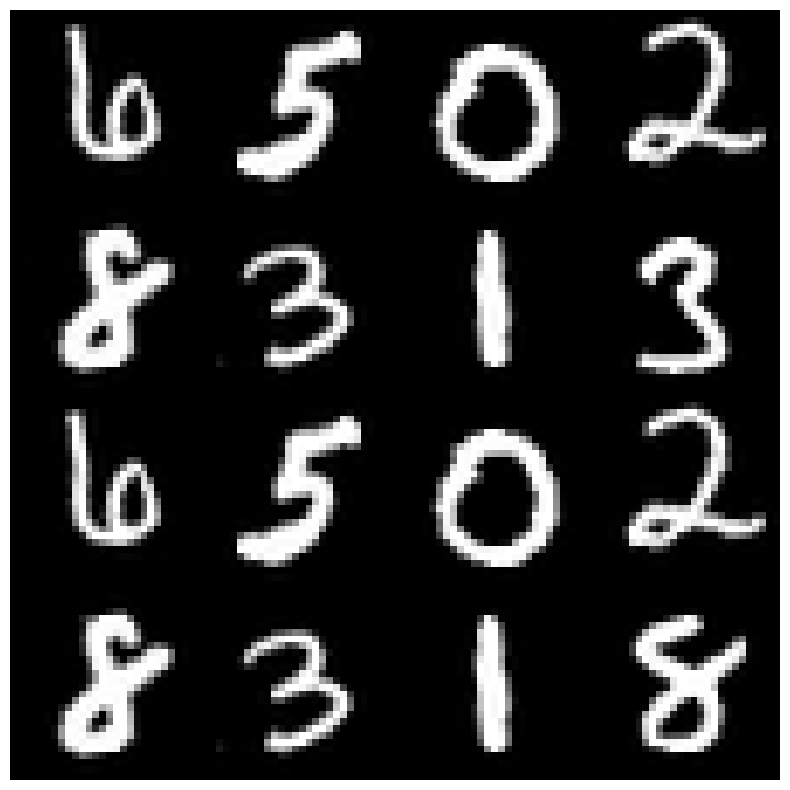

In [211]:
images = [next(datastream)[0, ...,0] for _ in range(16)]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [212]:
from probjax.nn.nets.unets import UNet

In [271]:
d = 784
class Denoiser(nnx.Module):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,128, rngs=rngs, learnable=True)
        self.net = UNet(1, rngs=rngs, kernel_size=(4,4), kernel_size_resnet=(3,3), out_features=[128,256,512], context_features=128, use_attention=False, use_bias=True, num_groups=8)
        self.out_layer = nnx.Conv(1,1,1, padding="SAME", kernel_init=nnx.initializers.zeros,use_bias=True, rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed)
        out = self.out_layer(out)
        return out

net = Denoiser(d, nnx.Rngs(1))
model = LinearFlow(net, std1=0.5)
#params = nnx.state(model, nnx.Param)

In [272]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  31611844


In [274]:
def loss_fn(params, x, rng):
    nnx.update(model, params)
    # rng1, rng2 = jax.random.split(rng, 2)
    # t = jax.random.uniform(rng1, (x.shape[0],1,1,1))
    # x0 = jax.random.normal(rng2, x.shape) * model.std0.value + model.mu0.value
    # xt = (1 - t) * x0 + t * x
    # ut = x - x0
    # v = model(t, xt)
    # diff = v - ut
    # loss = jnp.sum(diff**2, axis=(-3,-2,-1))
    # return jnp.mean(loss)
    return model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.5, adaptive_weight_eps=1e-3)








In [275]:
from functools import partial
import optax


opt = optax.chain(optax.adaptive_grad_clip(20.), optax.adam(5e-4))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0), 
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    grads = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_util.tree_map(lambda x: jnp.nan_to_num(x), params)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    rngs = jax.random.split(rng, jax.local_device_count())

    # Reshape xs to split across devices
    xs_split = jnp.reshape(xs, (jax.local_device_count(), -1, *xs.shape[1:]))

    params, opt_state, losses = update(params, opt_state, xs_split, rngs)
    return params, opt_state, jnp.mean(losses)


In [276]:
key = jax.random.key(2)

In [277]:
params_per_device, opt_state, loss = train_step(params_per_device, opt_state, next(datastream), key)

(256, 28, 28, 128)
(256, 14, 14, 256)
(256, 7, 7, 512)


In [285]:
# Example training iteration
for i in range(500):
    l = 0.
    for j in range(200): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datastream)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs, key_loss)
        l += loss
    print(l/200)

9.656088
9.643287
9.665407
9.648858
9.639653
9.653102
9.65086


KeyboardInterrupt: 

In [286]:
params = jax.tree_util.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

In [287]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (28,28,1,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(500) 

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) 
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")[-1]



In [288]:
keys = jax.random.split(jax.random.key(0), (16,))

In [289]:
xs = jax.vmap(sample)(keys)

(28, 28, 128)
(14, 14, 256)
(7, 7, 512)


In [290]:
xs.max()

Array(1.201, dtype=float32)

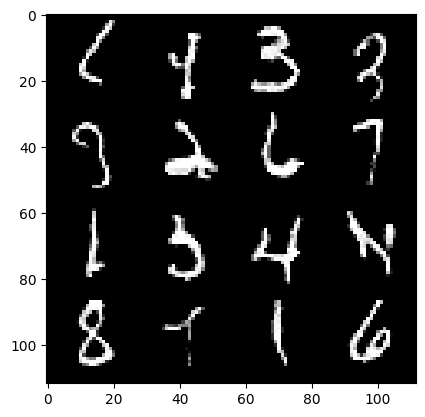

In [291]:
import matplotlib.pyplot as plt

img = xs.reshape(4, 4, 28, 28).transpose(0, 2, 1, 3).reshape(4*28, 4*28)
plt.imshow(img, cmap="gray", vmin=0, vmax=1.)